# Reflection + Evaluator-Optimizer

Agent가 자기 출력을 검토하고 개선하는 두 가지 패턴을 배운다.

| 패턴 | 핵심 | 평가 방식 |
|------|------|----------|
| **Reflection** | 생성 → 자기 검토 → 수정 루프 | 정성적 (자연어 피드백) |
| **Evaluator-Optimizer** | 생성 → 루브릭 채점 → 미달 항목 개선 | 정량적 (점수 + pass/fail) |

In [2]:
from dotenv import load_dotenv

load_dotenv()

True

## Reflection 패턴

가장 단순한 자기 개선 루프다.

```
START → generate → reflect → should_continue? → generate (반복)
                                              → END (종료)
```

동작 순서:

1. **generate** 노드가 초안을 작성한다
2. **reflect** 노드가 초안을 읽고 피드백을 준다 (톤, 빠진 정보, 길이 등)
3. **should_continue**가 반복 횟수를 체크한다 — 상한에 도달하면 종료
4. 종료 전이면 피드백을 반영해 다시 generate로 돌아간다

State에 `messages`를 누적하므로 generate 노드는 이전 피드백을 자연스럽게 참고한다.

## Reflection 실습

시나리오: 고객에게 보내는 사과 이메일 초안을 작성하고, 반복적으로 개선한다.

In [3]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage


class ReflectionState(TypedDict):
    messages: Annotated[list, add_messages]
    iteration: int


MAX_ITERATIONS = 3
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)

In [4]:
def generate(state: ReflectionState):
    """초안을 작성하거나 피드백을 반영해 수정한다."""
    system = SystemMessage(content=(
        "너는 고객 커뮤니케이션 전문가다. "
        "이전 피드백이 있으면 반영해서 이메일을 수정해. "
        "이메일 본문만 출력해."
    ))
    # 전체 messages를 넘기면 generate는 이전 피드백까지 자연스럽게 참고한다
    response = llm.invoke([system] + state["messages"])
    return {
        # name으로 역할을 구분한다 — reflect에서 generator의 메시지만 골라내기 위함
        "messages": [AIMessage(content=response.content, name="generator")],
        "iteration": state.get("iteration", 0) + 1,
    }


def reflect(state: ReflectionState):
    """초안을 검토하고 구체적인 피드백을 준다."""
    system = SystemMessage(content=(
        "너는 비즈니스 이메일 리뷰어다. "
        "다음 관점에서 피드백을 줘:\n"
        "1. 톤: 진정성 있는 사과인가?\n"
        "2. 빠진 정보: 구체적 해결 방안이 있는가?\n"
        "3. 길이: 간결한가?\n\n"
        "개선이 필요한 부분만 구체적으로 지적해. "
        "잘 된 부분은 언급하지 마."
    ))
    # 리뷰어는 최신 초안만 보면 된다 — 이전 대화 맥락 없이 객관적으로 평가
    last_ai = [m for m in state["messages"] if m.name == "generator"][-1]
    response = llm.invoke([system, HumanMessage(content=last_ai.content)])
    # HumanMessage로 넣는 이유: generate 노드의 LLM 입장에서 피드백은
    # "사용자 지시"처럼 작용해야 하므로 AIMessage가 아닌 HumanMessage로 넣는다
    return {
        "messages": [HumanMessage(content=response.content, name="reviewer")],
    }


def should_continue(state: ReflectionState):
    if state["iteration"] >= MAX_ITERATIONS:
        return "end"
    return "continue"

In [5]:
builder = StateGraph(ReflectionState)

builder.add_node("generate", generate)
builder.add_node("reflect", reflect)

builder.add_edge(START, "generate")
builder.add_edge("generate", "reflect")
builder.add_conditional_edges(
    "reflect",
    should_continue,
    {"continue": "generate", "end": END},
)

reflection_graph = builder.compile()

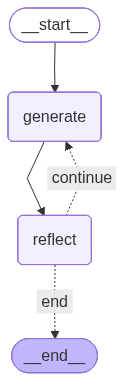

In [6]:
from IPython.display import Image, display

display(Image(reflection_graph.get_graph().draw_mermaid_png()))

In [7]:
task = "배송이 2주 지연된 고객에게 사과 이메일을 작성해줘. 고객명: 김민수, 주문번호: ORD-2024-1234"

result = reflection_graph.invoke(
    {"messages": [HumanMessage(content=task)], "iteration": 0}
)

print(f"총 반복 횟수: {result['iteration']}")
print(f"총 메시지 수: {len(result['messages'])}")
print("\n" + "=" * 60)

for msg in result["messages"]:
    name = getattr(msg, "name", None) or msg.type
    print(f"\n[{name}]")
    print(msg.content[:500])
    print("-" * 40)

총 반복 횟수: 3
총 메시지 수: 7


[human]
배송이 2주 지연된 고객에게 사과 이메일을 작성해줘. 고객명: 김민수, 주문번호: ORD-2024-1234
----------------------------------------

[generator]
안녕하세요, 김민수님.

먼저, 주문번호 ORD-2024-1234의 배송이 2주 지연된 점 진심으로 사과드립니다. 고객님께 불편을 드려 매우 죄송합니다.

저희는 고객님께서 기대하시는 서비스와 품질을 제공하기 위해 최선을 다하고 있으며, 이번 지연은 예상치 못한 상황으로 인해 발생한 것임을 알려드립니다. 현재 배송 상황을 면밀히 모니터링하고 있으며, 최대한 빠르게 해결하도록 하겠습니다.

기다려 주신 것에 대해 깊이 감사드리며, 추가적인 문의사항이나 필요하신 부분이 있으시면 언제든지 저희 고객센터로 연락해 주시기 바랍니다.

다시 한번 불편을 드린 점 사과드리며, 조속히 제품을 받아보실 수 있도록 최선을 다하겠습니다.

감사합니다.

[귀사의 이름]  
[귀사의 연락처]  
[귀사의 회사명]  
----------------------------------------

[reviewer]
1. 톤: 사과는 진정성 있게 표현되었지만, 고객의 불편을 더 깊이 공감하는 표현이 추가된다면 더욱 효과적일 것입니다. 예를 들어, 고객의 기대를 저버린 점에 대한 구체적인 이해와 공감의 표현이 필요합니다.

2. 빠진 정보: 구체적인 해결 방안이 부족합니다. 배송 지연의 원인이나 예상되는 새로운 배송 일정에 대한 정보가 포함된다면 고객이 상황을 이해하는 데 도움이 될 것입니다.

3. 길이: 전반적으로 내용이 다소 길게 느껴질 수 있습니다. 핵심 메시지를 간결하게 전달하기 위해 불필요한 반복이나 장황한 표현을 줄이면 좋겠습니다.
----------------------------------------

[generator]
안녕하세요, 김민수님.

주문번호 ORD-2024-1234의 배송이 2주 지연된 점 진심으로 사

반복할수록 피드백이 반영되어 품질이 올라가는 것을 확인할 수 있다. 하지만 Reflection에는 한계가 있다.

- 피드백이 **자연어**라서 "얼마나 좋아졌는지" 정량화할 수 없다
- "충분히 좋다"의 기준이 없으므로 항상 `max_iterations`까지 반복한다
- 반복할수록 피드백이 점점 미세해진다 — 위 출력에서도 3번째 리뷰어는 "깊이 유감스럽게" → "진심으로 안타깝게" 같은 표현 수준의 차이만 지적하는데, 이것이 실질적 개선인지 알 수 없다
- 반복이 많아지면 원래 의도에서 벗어나거나 과하게 수정되는 경우도 있다 (항상 품질이 올라가는 것은 아니다)

이 문제를 해결하는 것이 Evaluator-Optimizer 패턴이다.

## Evaluator-Optimizer 패턴

Reflection과 구조는 비슷하지만 핵심 차이가 있다.

| | Reflection | Evaluator-Optimizer |
|---|---|---|
| 평가 방식 | 자연어 피드백 | 점수 (1~10) + pass/fail |
| 종료 조건 | 고정 횟수 | 점수 기준 달성 시 조기 종료 |
| 개선 지시 | 전체적 피드백 | 미달 항목만 타겟팅 |
| 재현성 | 낮음 | 높음 (루브릭 고정) |

```
START → generate → evaluate → pass? → END
                      ↓ fail
                   optimize → generate (재시도)
```

시나리오: 마케팅 카피 생성. 루브릭으로 채점하고 미달 시 개선한다.

## 루브릭 설계

루브릭(Rubric)은 **평가 항목과 점수 기준을 정리한 채점표**다. 좋은 루브릭은 구체적이고 측정 가능하다.

| 나쁜 루브릭 | 좋은 루브릭 |
|------------|------------|
| "매력적인가?" | "감정을 자극하는 단어가 1개 이상 포함되어 있는가?" |
| "적절한 길이인가?" | "50자 이상 150자 이하인가?" |
| "좋은 카피인가?" | "행동 유도(CTA)가 포함되어 있는가?" |

Pydantic 모델로 평가 결과를 구조화한다.

In [8]:
from pydantic import BaseModel, Field


class CriterionScore(BaseModel):
    name: str = Field(description="평가 항목명")
    score: int = Field(description="1~10 점수", ge=1, le=10)
    reason: str = Field(description="점수 근거 (1문장)")


class EvaluationResult(BaseModel):
    criteria: list[CriterionScore] = Field(description="각 항목별 평가")
    summary: str = Field(description="전체 평가 요약 (1~2문장)")

루브릭은 도메인마다 완전히 달라진다. 마케팅 카피라면 "감정 자극, CTA 포함, 글자 수", 기술 문서라면 "정확성, 재현 가능성, 코드 포함" 등이 핵심 기준이 된다. 설계할 때는 해당 도메인의 핵심 품질 기준을 먼저 정의하고, 각 기준을 측정 가능한 형태로 변환한 뒤, 점수 척도와 합격 기준을 설정한다.

## State와 노드 설계

```python
class EvalOptState(TypedDict):
    task: str          # 입력: 카피 작성 지시
    copy: str          # 현재 카피
    evaluation: dict   # EvaluationResult를 dict로 저장
    iteration: int     # 반복 횟수
    history: list      # 이전 시도 기록 (리듀서: operator.add)
```

`history`의 각 원소는 다음 구조다:

```python
{
    "copy": "이전에 생성한 카피",
    "evaluation": { ... },       # EvaluationResult.model_dump() 결과
    "improvement": "미달 항목에 대한 개선 지시",
}
```

노드별 역할:

| 노드 | 입력 | 출력 | 역할 |
|------|------|------|------|
| `generate` | task, history | copy | 카피 생성 (history가 있으면 개선 지시 반영) |
| `evaluate` | copy | evaluation, iteration | 루브릭으로 채점 (Structured Output) |
| `optimize` | copy, evaluation | history | 미달 항목만 골라 개선 지시 작성 |

In [9]:
from operator import add


class EvalOptState(TypedDict):
    task: str
    copy: str
    evaluation: dict  # EvaluationResult를 dict로 저장
    iteration: int
    history: Annotated[list, add]


MAX_ITERATIONS = 4
PASS_THRESHOLD = 8
eval_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [10]:
def generate_copy(state: EvalOptState):
    """마케팅 카피를 생성한다. 이전 평가가 있으면 optimize 노드의 지시를 참고한다."""
    task = state["task"]
    history = state.get("history", [])

    if history:
        last = history[-1]
        prompt = (
            f"작업: {task}\n\n"
            f"이전 카피:\n{last['copy']}\n\n"
            f"개선 지시:\n{last['improvement']}\n\n"
            "위 지시를 반영해서 카피를 다시 작성해. 카피만 출력해."
        )
    else:
        prompt = f"다음 마케팅 카피를 작성해. 카피만 출력해.\n\n작업: {task}"

    response = llm.invoke(prompt)
    return {"copy": response.content}


def evaluate_copy(state: EvalOptState):
    """루브릭에 따라 카피를 채점한다. Structured Output 사용."""
    copy = state["copy"]
    evaluator = eval_llm.with_structured_output(EvaluationResult)

    result = evaluator.invoke(f"""\
다음 마케팅 카피를 평가해.

카피:
{copy}

평가 기준 (각 1~10점):
1. clarity: 메시지가 명확하고 이해하기 쉬운가?
2. emotion: 감정을 자극하는 표현이 있는가?
3. cta: 행동 유도(구매, 클릭 등)가 포함되어 있는가?
4. conciseness: 간결한가? (불필요한 표현 없는가?)""")

    # pass/fail 판정은 LLM이 아닌 코드로 수행한다 — 점수 기반 판정의 핵심은 재현성이다
    evaluation = result.model_dump()
    evaluation["overall_pass"] = all(
        c["score"] >= PASS_THRESHOLD for c in evaluation["criteria"]
    )

    return {
        "evaluation": evaluation,
        "iteration": state.get("iteration", 0) + 1,
    }


def optimize_copy(state: EvalOptState):
    """미달 항목만 골라서 구체적인 개선 지시를 만든다."""
    evaluation = state["evaluation"]
    failed = [c for c in evaluation["criteria"] if c["score"] < PASS_THRESHOLD]
    items = "\n".join(
        f"- {c['name']} ({c['score']}점): {c['reason']}" for c in failed
    )

    return {
        "history": [{
            "copy": state["copy"],
            "evaluation": evaluation,
            "improvement": f"다음 항목을 개선해:\n{items}",
        }],
    }


def should_continue_eval(state: EvalOptState):
    if state["evaluation"]["overall_pass"]:
        return "end"
    if state["iteration"] >= MAX_ITERATIONS:
        return "end"  # 상한 도달 시에도 종료
    return "fail"

In [11]:
builder = StateGraph(EvalOptState)

builder.add_node("generate", generate_copy)
builder.add_node("evaluate", evaluate_copy)
builder.add_node("optimize", optimize_copy)

builder.add_edge(START, "generate")
builder.add_edge("generate", "evaluate")
builder.add_conditional_edges(
    "evaluate",
    should_continue_eval,
    {"end": END, "fail": "optimize"},
)
builder.add_edge("optimize", "generate")

eval_opt_graph = builder.compile()

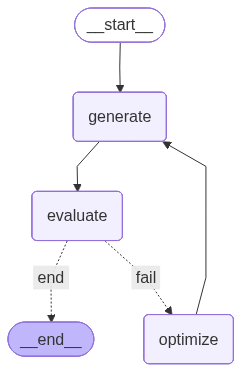

In [12]:
display(Image(eval_opt_graph.get_graph().draw_mermaid_png()))

In [14]:
task = "AI 기반 영어 학습 앱 'SmartLingo' 출시 광고 카피. 타겟: 20~30대 직장인. 핵심 가치: 출퇴근 10분으로 영어 실력 향상."

for event in eval_opt_graph.stream({"task": task, "iteration": 0, "history": []}):
    node_name = list(event.keys())[0]
    state_update = event[node_name]

    if node_name == "generate":
        print(f"\n{'=' * 60}")
        print(f"[generate] 카피 생성")
        print(state_update["copy"])

    elif node_name == "evaluate":
        iteration = state_update["iteration"]
        evaluation = state_update["evaluation"]
        status = "PASS ✓" if evaluation["overall_pass"] else "FAIL ✗"
        print(f"\n[evaluate] 반복 {iteration} — {status}")
        for c in evaluation["criteria"]:
            mark = "PASS" if c["score"] >= PASS_THRESHOLD else "FAIL"
            print(f"  {c['name']}: {c['score']}/10 ({mark}) - {c['reason']}")

    elif node_name == "optimize":
        h = state_update["history"][0]
        print(f"\n[optimize] 개선 지시")
        print(h["improvement"])


[generate] 카피 생성
"출퇴근 10분, SmartLingo와 함께라면 영어가 내 손안에! 바쁜 일상 속에서도 손쉽게 실력을 쌓아보세요. 당신의 영어, 이제는 스마트하게!"

[evaluate] 반복 1 — FAIL ✗
  clarity: 9/10 (PASS) - 메시지가 명확하고 이해하기 쉬워, 독자가 쉽게 이해할 수 있다.
  emotion: 7/10 (FAIL) - '바쁜 일상 속에서도 손쉽게'라는 표현이 감정을 자극하지만, 더 강한 감정적 연결이 필요하다.
  cta: 6/10 (FAIL) - 직접적인 행동 유도는 부족하지만, '실력을 쌓아보세요'라는 간접적인 유도가 있다.
  conciseness: 8/10 (PASS) - 전반적으로 간결하지만, '이제는 스마트하게' 부분이 다소 중복된 느낌을 줄 수 있다.

[optimize] 개선 지시
다음 항목을 개선해:
- emotion (7점): '바쁜 일상 속에서도 손쉽게'라는 표현이 감정을 자극하지만, 더 강한 감정적 연결이 필요하다.
- cta (6점): 직접적인 행동 유도는 부족하지만, '실력을 쌓아보세요'라는 간접적인 유도가 있다.

[generate] 카피 생성
"매일 아침 출퇴근 10분, SmartLingo와 함께라면 당신의 영어가 꿈이 아닌 현실이 됩니다. 지친 일상 속에서도 작은 변화가 큰 성장을 가져옵니다. 지금 바로 시작해보세요! 당신의 영어, SmartLingo와 함께 한 걸음 더 나아가세요!"

[evaluate] 반복 2 — FAIL ✗
  clarity: 9/10 (PASS) - 메시지가 명확하고 이해하기 쉬우며, 영어 학습의 가능성을 잘 전달하고 있다.
  emotion: 8/10 (PASS) - '작은 변화가 큰 성장을 가져옵니다'와 같은 표현이 감정을 자극한다.
  cta: 9/10 (PASS) - '지금 바로 시작해보세요!'와 같은 강력한 행동 유도가 포함되어 있다.
  conciseness: 7/10 (FAIL) - 전체적으로 간결하지만, 약간의 중복 표현이 있어 

핵심 포인트:

- `evaluate` 노드가 Structured Output으로 **정량 점수**를 반환한다
- `overall_pass` 판정은 LLM이 아닌 **코드로** 수행한다 — 점수를 매기는 건 LLM, 합격 여부는 코드가 결정
- `overall_pass`로 **조기 종료**가 가능하다 (불필요한 반복 방지)
- `optimize` 노드가 **미달 항목만** 타겟팅한다 (이미 좋은 부분은 건드리지 않음)
- `MAX_ITERATIONS`로 무한 반복을 방지한다

주의: 이 예제에서는 같은 LLM이 생성과 평가를 모두 수행한다. 실무에서는 평가에 더 강한 모델을 쓰거나, 생성 모델과 별도의 모델을 사용해서 자기 평가 편향(self-evaluation bias)을 줄이기도 한다.

## Evaluator를 테스트에 재활용하기

Evaluator-Optimizer의 채점 로직은 품질 테스트에 그대로 재활용할 수 있다. 테스트 케이스(입력-기대 품질 기준 쌍)를 미리 작성해두고, 프롬프트를 변경할 때마다 실행해서 점수가 떨어진 케이스가 있는지 확인한다. 프롬프트를 수정하면 기존에 잘 되던 케이스가 망가질 수 있기 때문에, 이런 회귀 테스트가 중요하다. 테스트 케이스는 점진적으로 추가하면 되고, 실무에서는 CI/CD에 넣어 자동화하기도 한다.

## 실습: 제품 리뷰 요약

아래 제품 리뷰를 **한 문단(3~5문장)**으로 요약하는 과제를 두 가지 패턴으로 구현한다.

1. **Part 1 — Reflection**: generate → reflect → should_continue 루프
2. **Part 2 — Evaluator-Optimizer**: generate → evaluate → optimize 루프

실무에서 Evaluator-Optimizer를 쓸 때 **루브릭 설계가 가장 중요한 단계**다. 루브릭이 모호하면 점수가 들쭉날쭉해서 Reflection과 다를 바 없고, 루브릭이 구체적이면 개선 방향이 명확해진다.

### 샘플 리뷰 데이터

In [ ]:
REVIEW = """\
[무선 블루투스 이어폰 - StarBuds Pro 리뷰]

저는 이 이어폰을 출퇴근용으로 3개월째 사용하고 있습니다. 먼저 음질은 가격대비 정말 \
훌륭합니다. 저음이 풍부하고 고음도 깨끗하게 들립니다. 특히 팟캐스트를 들을 때 목소리가 \
또렷하게 들려서 좋습니다.

노이즈 캔슬링은 지하철에서 테스트해봤는데, 완전 차단까지는 아니지만 주변 소음을 \
70~80% 정도 줄여줍니다. 출퇴근 시 음악 감상에는 충분합니다. 다만 바람이 부는 야외에서는 \
노캔 성능이 많이 떨어집니다.

배터리는 공식 스펙이 7시간인데 실사용 5시간 반 정도 갑니다. 노캔 켜면 4시간 정도로 \
줄어듭니다. 케이스 충전 포함하면 총 20시간 정도 사용 가능합니다.

착용감은 제 귀에는 잘 맞는데, 귀가 작은 아내는 30분만 끼면 아프다고 합니다. 이어팁이 \
3종류 들어있긴 한데 가장 작은 것도 좀 큰 편입니다.

통화 품질은 솔직히 별로입니다. 상대방이 제 목소리가 멀리서 들린다고 합니다. \
조용한 실내에서는 괜찮은데 밖에서는 통화하기 어렵습니다.

앱 연동은 EQ 조절이 가능하고 노캔 강도도 조절할 수 있어서 편리합니다. \
다만 앱이 가끔 블루투스 연결이 끊기는 버그가 있습니다.

총평: 7만원대에 이 정도면 가성비 좋습니다. 통화보다 음악 감상 위주로 쓸 분께 추천합니다. \
통화를 많이 하시는 분은 다른 제품을 알아보시는 게 좋을 것 같습니다.
"""

print(REVIEW)

### Part 1: Reflection으로 리뷰 요약

위에서 배운 Reflection 패턴을 사용해서 리뷰 요약 그래프를 구현해라.

- generate 노드 시스템 프롬프트: "너는 제품 리뷰 요약 전문가다. 긴 리뷰를 한 문단(3~5문장)으로 요약해. 장점, 단점, 추천 대상을 균형 있게 포함해. 이전 피드백이 있으면 반영해서 수정해. 요약문만 출력해."
- reflect 노드 시스템 프롬프트: "너는 제품 리뷰 요약 편집자다. 다음 관점에서 피드백을 줘: 1. 정보 누락: 원문의 핵심 정보가 빠졌는가? 2. 균형: 장점과 단점이 균형 있게 반영되었는가? 3. 간결성: 불필요한 표현이 있는가? 4. 구체성: 모호한 표현 대신 구체적 수치나 사례가 있는가? 개선이 필요한 부분만 구체적으로 지적해."

In [ ]:
# 여기에 코드를 작성하세요


In [ ]:
# 실행
task = f"다음 제품 리뷰를 한 문단(3~5문장)으로 요약해줘.\n\n{REVIEW}"

result = review_reflection_graph.invoke(
    {"messages": [HumanMessage(content=task)], "iteration": 0}
)

print(f"총 반복 횟수: {result['iteration']}")
print(f"총 메시지 수: {len(result['messages'])}")
print("\n" + "=" * 60)

for msg in result["messages"]:
    name = getattr(msg, "name", None) or msg.type
    print(f"\n[{name}]")
    print(msg.content[:500])
    print("-" * 40)

### Part 2: Evaluator-Optimizer로 리뷰 요약

같은 리뷰를 Evaluator-Optimizer 패턴으로 요약한다.

- generate 노드: Part 1과 동일하게 리뷰 요약을 생성한다. history가 있으면 이전 요약과 개선 지시를 참고한다.
- evaluate 노드: `EvaluationResult`를 Structured Output으로 받고, 아래 루브릭으로 채점한다.
- optimize 노드: 미달 항목(PASS_THRESHOLD 미만)만 골라서 개선 지시를 만든다.

루브릭 (각 1~10점):
1. completeness: 원문의 핵심 정보(음질, 노캔, 배터리, 착용감, 통화, 가격)가 빠짐없이 반영되었는가?
2. balance: 장점과 단점이 한쪽에 치우치지 않고 균형 있게 서술되었는가?
3. conciseness: 3~5문장 이내로 간결하게 작성되었는가? 불필요한 수식어가 없는가?
4. recommendation: 어떤 사용자에게 적합하고 어떤 사용자에게 부적합한지 명확히 언급했는가?

In [ ]:
# 여기에 코드를 작성하세요


In [ ]:
# 실행
result = review_eval_opt_graph.invoke({
    "task": REVIEW,
    "iteration": 0,
    "history": [],
})

print(f"반복 횟수: {result['iteration']}")
print(f"통과 여부: {result['evaluation']['overall_pass']}")
print()
print("[최종 요약]")
print(result["summary"])
print()
print("[최종 평가]")
for c in result["evaluation"]["criteria"]:
    status = "PASS" if c["score"] >= PASS_THRESHOLD else "FAIL"
    print(f"  {c['name']}: {c['score']}/10 ({status}) - {c['reason']}")

In [ ]:
# 개선 과정 추적
if result.get("history"):
    for i, h in enumerate(result["history"]):
        print(f"\n--- 시도 {i + 1} ---")
        print(f"요약: {h['summary'][:100]}...")
        scores = {c["name"]: c["score"] for c in h["evaluation"]["criteria"]}
        print(f"점수: {scores}")
        print(f"개선 지시: {h['improvement'][:200]}")
else:
    print("첫 시도에 통과했다.")